# Notebook 2: Extreme Value Theory (EVT)

Modeling tail losses using Peaks Over Threshold (POT) with Generalized Pareto Distribution (GPD).

Why EVT: standard distributions underestimate extreme events that reinsurers care about most.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from evt_models import ExtremeValueAnalysis, hill_estimator

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load Portfolio

In [2]:
df = pd.read_csv('../data/processed/claims_cleaned.csv')
losses = df['loss'].values
print(f'Total claims loaded: {len(losses):,}')

Total claims loaded: 50,000


## 2. Hill Estimator

The Hill estimator measures the tail index (alpha). A lower alpha means a heavier tail.
Values below 2 indicate infinite variance — a key signal for reinsurers.

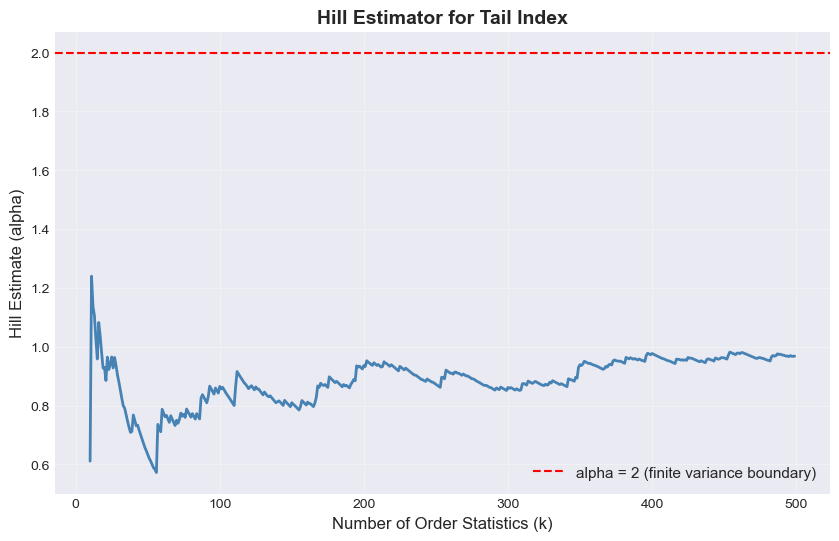

In [3]:
k_values, hill_estimates = hill_estimator(losses)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_values, hill_estimates, linewidth=2, color='steelblue')
ax.set_xlabel('Number of Order Statistics (k)', fontsize=12)
ax.set_ylabel('Hill Estimate (alpha)', fontsize=12)
ax.set_title('Hill Estimator for Tail Index', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=2, color='red', linestyle='--', linewidth=1.5, label='alpha = 2 (finite variance boundary)')
ax.legend(fontsize=11)

plt.savefig('../results/figures/05_hill_estimator.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Select Threshold and Fit GPD

POT approach: model only exceedances above a threshold.
Threshold = 95th percentile. GPD is fitted to exceedances using MLE.

In [4]:
eva = ExtremeValueAnalysis(losses)
threshold = eva.select_threshold(method='percentile', value=95)
gpd_params = eva.fit_gpd()

Threshold selected: 4,925.36
Number of exceedances: 2499 (5.00%)

GPD Parameters fitted:
  Shape (xi): 1.0010
  Scale (sigma): 3,406.20
  Location: 0.40
  Interpretation: Heavy tail (Pareto-type)


## 4. VaR and TVaR

VaR (Value at Risk): loss not exceeded with probability alpha.
TVaR (Tail VaR / Expected Shortfall): expected loss given that VaR is exceeded.
TVaR is the preferred metric for reinsurers and Solvency II capital models.

In [5]:
risk_metrics = eva.calculate_var_tvar(confidence_levels=[0.90, 0.95, 0.99, 0.995, 0.999])

print('Risk Metrics: GPD vs Empirical')
print(risk_metrics.to_string(index=False))

risk_metrics.to_csv('../results/tables/risk_metrics.csv', index=False)
print('\nSaved to results/tables/risk_metrics.csv')

Risk Metrics: GPD vs Empirical
 confidence       VaR_GPD  VaR_Empirical  TVaR_GPD  TVaR_Empirical
      0.900   3222.084615       2812.304       NaN    14612.009510
      0.950   4923.997522       4925.360       NaN    25615.394778
      0.990  18556.609063      18825.380       NaN    95008.072926
      0.995  35613.532930      39071.070       NaN   163898.149476
      0.999 172242.391101     182500.000       NaN   523892.161633

Saved to results/tables/risk_metrics.csv


## 5. Goodness of Fit


Kolmogorov-Smirnov Test:
  Statistic: 0.0328
  P-value: 0.0091
  Result: Reject H0 - GPD may not be ideal (p < 0.05)


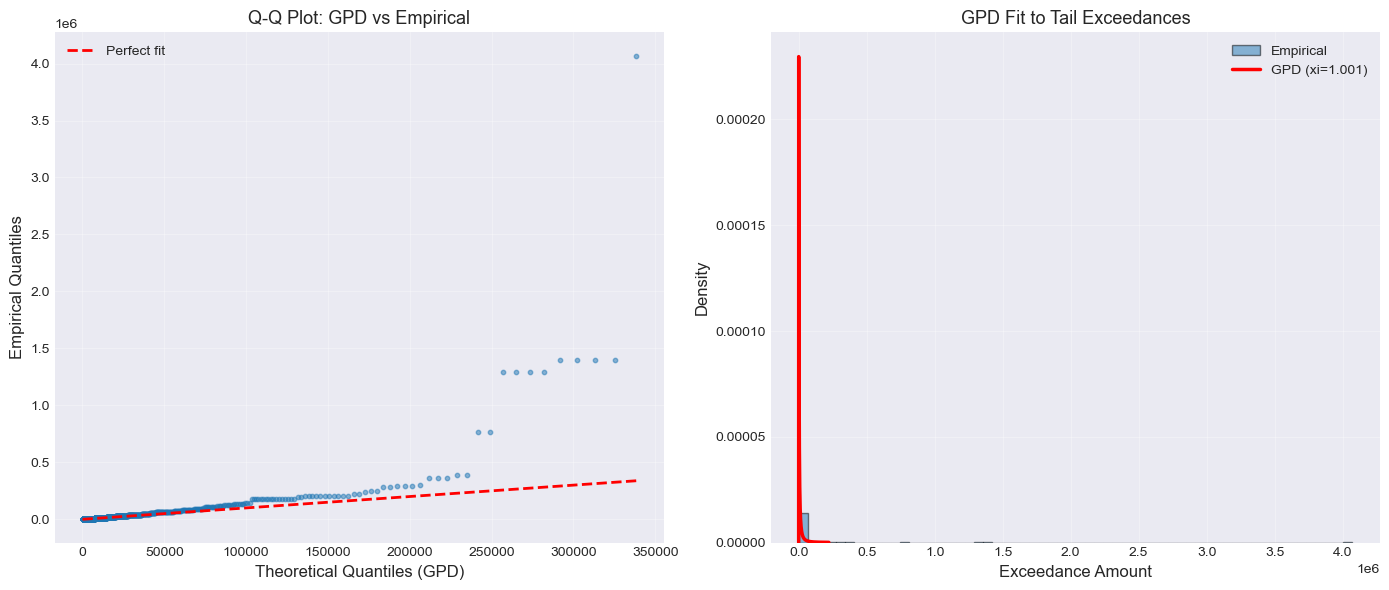

In [6]:
theor_q, emp_q, ks_stat, p_val = eva.goodness_of_fit()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Q-Q Plot
axes[0].scatter(theor_q, emp_q, alpha=0.5, s=10)
axes[0].plot([theor_q.min(), theor_q.max()], [theor_q.min(), theor_q.max()],
             'r--', linewidth=2, label='Perfect fit')
axes[0].set_xlabel('Theoretical Quantiles (GPD)', fontsize=12)
axes[0].set_ylabel('Empirical Quantiles', fontsize=12)
axes[0].set_title('Q-Q Plot: GPD vs Empirical', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Density comparison
shape, loc, scale = gpd_params
exceedances = losses[losses > threshold] - threshold
x = np.linspace(0, np.percentile(exceedances, 99), 500)

axes[1].hist(exceedances, bins=60, density=True, alpha=0.5, label='Empirical', edgecolor='black')
gpd_pdf = stats.genpareto.pdf(x, shape, loc, scale)
axes[1].plot(x, gpd_pdf, 'r-', linewidth=2.5, label=f'GPD (xi={shape:.3f})')
axes[1].set_xlabel('Exceedance Amount', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('GPD Fit to Tail Exceedances', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/06_gpd_fit.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Return Period Analysis

Return period T: expected loss that occurs once every T years.
This is how reinsurers communicate extreme event severity (e.g. 1-in-100-year loss).

Return Period Analysis:
 return_period  annual_prob  expected_loss
            10        0.100    3222.084615
            20        0.050    4923.997522
            50        0.020   10033.840225
           100        0.010   18556.609063
           200        0.005   35613.532930
           500        0.002   86825.435492


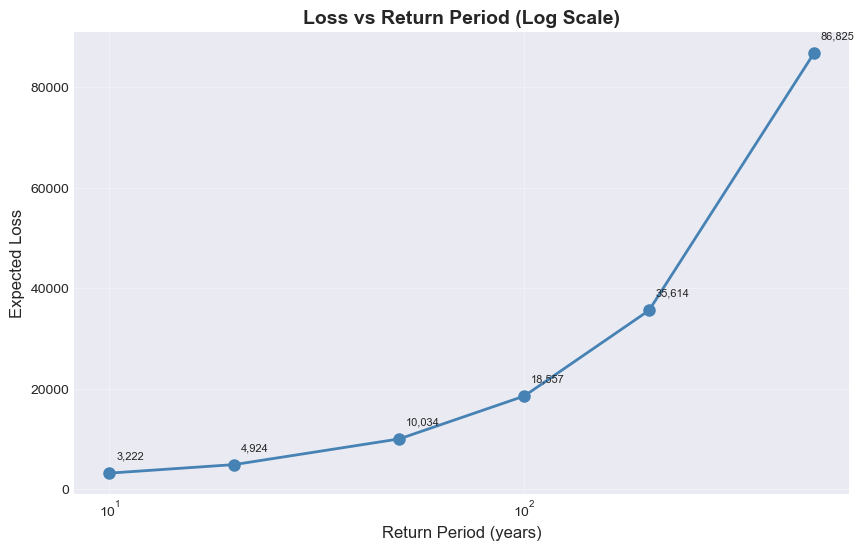

In [7]:
return_periods = eva.return_period_loss(return_periods=[10, 20, 50, 100, 200, 500])

print('Return Period Analysis:')
print(return_periods.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(return_periods['return_period'], return_periods['expected_loss'],
        marker='o', linewidth=2, markersize=8, color='steelblue')

for _, row in return_periods.iterrows():
    ax.annotate(f"{row['expected_loss']:,.0f}",
                xy=(row['return_period'], row['expected_loss']),
                xytext=(5, 10), textcoords='offset points', fontsize=8)

ax.set_xlabel('Return Period (years)', fontsize=12)
ax.set_ylabel('Expected Loss', fontsize=12)
ax.set_title('Loss vs Return Period (Log Scale)', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.savefig('../results/figures/07_return_periods.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Summary of EVT Results

In [8]:
print('=' * 60)
print('EVT SUMMARY')
print('=' * 60)
shape, loc, scale = gpd_params
print(f'  Threshold (P95):   {threshold:>15,.2f}')
print(f'  GPD Shape (xi):    {shape:>15.4f}')
print(f'  GPD Scale (sigma): {scale:>15.2f}')
print(f'  Tail type:         {"Heavy (Pareto)" if shape > 0 else "Light"}')
print(f'  KS p-value:        {p_val:>15.4f}')
print('=' * 60)

EVT SUMMARY
  Threshold (P95):          4,925.36
  GPD Shape (xi):             1.0010
  GPD Scale (sigma):         3406.20
  Tail type:         Heavy (Pareto)
  KS p-value:                 0.0091
